In [ ]:
# Unified Data Access Pipeline using PostgreSQL, Google Drive, and Supabase

In [1]:
!pip install -q psycopg2-binary supabase gdown pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 4.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

random.seed(42)
np.random.seed(42)

customers = [
    "Aarav Kumar", "Priya Sharma", "Rahul Verma", "Sneha Reddy",
    "Vikram Singh", "Ananya Iyer", "Karthik Raj", "Meera Nair"
]

categories = {
    "Electronics": [
        ("Wireless Mouse", 799),
        ("Bluetooth Speaker", 2499),
        ("Power Bank", 1499),
        ("USB-C Charger", 999),
    ],
    "Fashion": [
        ("Cotton T-Shirt", 599),
        ("Running Shoes", 2999),
        ("Backpack", 1999),
    ],
    "Home & Kitchen": [
        ("Water Bottle", 499),
        ("Mixer Grinder", 3499),
        ("Coffee Mug", 299),
    ],
    "Books": [
        ("Python for Data Science", 899),
        ("Machine Learning Handbook", 1299),
        ("Deep Learning Basics", 999),
    ],
}

cities = [
    "Chennai", "Bengaluru", "Hyderabad",
    "Mumbai", "Delhi", "Coimbatore"
]

payment_methods = [
    "UPI", "Credit Card", "Debit Card",
    "Net Banking", "Cash on Delivery"
]

order_statuses = [
    "Delivered", "Shipped", "Processing",
    "Cancelled", "Returned"
]

rows = []

for i in range(1, 101):
    customer = random.choice(customers)
    category = random.choice(list(categories.keys()))
    product_name, unit_price = random.choice(categories[category])
    quantity = random.randint(1, 5)
    total_amount = quantity * unit_price

    rows.append({
        "order_id": f"ORD{i:04d}",
        "customer_name": customer,
        "product_category": category,
        "product_name": product_name,
        "quantity": quantity,
        "unit_price": unit_price,
        "total_amount": total_amount,
        "order_date": (
            datetime(2025, 1, 1) +
            timedelta(days=random.randint(0, 180))
        ).strftime("%Y-%m-%d"),
        "city": random.choice(cities),
        "payment_method": random.choice(payment_methods),
        "order_status": random.choice(order_statuses),
    })

ecommerce_df = pd.DataFrame(rows)

print("Dataset shape:", ecommerce_df.shape)
ecommerce_df.head()

Dataset shape: (100, 11)


,order_id,customer_name,product_category,product_name,quantity,unit_price,total_amount,order_date,city,payment_method,order_status
0,ORD0001,Priya Sharma,Electronics,Power Bank,2,1499,2998,2025-02-27,Bengaluru,UPI,Returned
1,ORD0002,Priya Sharma,Books,Python for Data Science,1,899,899,2025-01-24,Bengaluru,Credit Card,Returned
2,ORD0003,Aarav Kumar,Fashion,Backpack,5,1999,9995,2025-04-18,Bengaluru,Net Banking,Returned
3,ORD0004,Vikram Singh,Electronics,Bluetooth Speaker,4,2499,9996,2025-03-29,Hyderabad,Credit Card,Shipped
4,ORD0005,Ananya Iyer,Electronics,Wireless Mouse,4,799,3196,2025-01-25,Hyderabad,Debit Card,Returned


In [4]:
ecommerce_df.to_csv("ecommerce_orders.csv", index=False)
print("Dataset saved as ecommerce_orders.csv")

Dataset saved as ecommerce_orders.csv


In [5]:
!pip install -q psycopg2-binary sqlalchemy

In [6]:
from sqlalchemy import create_engine

In [7]:
# PostgreSQL Configuration (Neon)

POSTGRES_CONFIG = {
    "host": "ep-lingering-hill-ao82ubvf.c-2.ap-southeast-1.aws.neon.tech",
    "port": 5432,
    "database": "neondb",
    "user": "neondb_owner",
    "password": "npg_0PsNSel4uWZA",
}

In [27]:
# Create SQLAlchemy Engine

from sqlalchemy import create_engine

connection_string = (
    f"postgresql+psycopg2://"
    f"{POSTGRES_CONFIG['user']}:"
    f"{POSTGRES_CONFIG['password']}@"
    f"{POSTGRES_CONFIG['host']}:"
    f"{POSTGRES_CONFIG['port']}/"
    f"{POSTGRES_CONFIG['database']}"
    f"?sslmode=require"
)

engine = create_engine(connection_string)

print("PostgreSQL connection successful!")

PostgreSQL connection successful!


In [9]:
# Upload E-Commerce Dataset to PostgreSQL

ecommerce_df.to_sql(
    "ecommerce_orders",
    engine,
    if_exists="replace",
    index=False
)

print("Dataset uploaded to PostgreSQL successfully!")

Dataset uploaded to PostgreSQL successfully!


In [10]:
# Retrieve Data from PostgreSQL

postgres_df = pd.read_sql(
    "SELECT * FROM ecommerce_orders LIMIT 10;",
    engine
)

postgres_df.head()

,order_id,customer_name,product_category,product_name,quantity,unit_price,total_amount,order_date,city,payment_method,order_status
0,ORD0001,Priya Sharma,Electronics,Power Bank,2,1499,2998,2025-02-27,Bengaluru,UPI,Returned
1,ORD0002,Priya Sharma,Books,Python for Data Science,1,899,899,2025-01-24,Bengaluru,Credit Card,Returned
2,ORD0003,Aarav Kumar,Fashion,Backpack,5,1999,9995,2025-04-18,Bengaluru,Net Banking,Returned
3,ORD0004,Vikram Singh,Electronics,Bluetooth Speaker,4,2499,9996,2025-03-29,Hyderabad,Credit Card,Shipped
4,ORD0005,Ananya Iyer,Electronics,Wireless Mouse,4,799,3196,2025-01-25,Hyderabad,Debit Card,Returned


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import os

project_folder = "/content/drive/MyDrive/internship_data_pipeline"
os.makedirs(project_folder, exist_ok=True)

print("Project folder created:", project_folder)

Project folder created: /content/drive/MyDrive/internship_data_pipeline


In [14]:
drive_csv_path = f"{project_folder}/ecommerce_orders.csv"

ecommerce_df.to_csv(drive_csv_path, index=False)

print("Dataset saved to Google Drive successfully!")
print("Saved at:", drive_csv_path)

Dataset saved to Google Drive successfully!
Saved at: /content/drive/MyDrive/internship_data_pipeline/ecommerce_orders.csv


In [15]:
drive_df = pd.read_csv(drive_csv_path)

print("Dataset loaded from Google Drive successfully!")
drive_df.head()

Dataset loaded from Google Drive successfully!


,order_id,customer_name,product_category,product_name,quantity,unit_price,total_amount,order_date,city,payment_method,order_status
0,ORD0001,Priya Sharma,Electronics,Power Bank,2,1499,2998,2025-02-27,Bengaluru,UPI,Returned
1,ORD0002,Priya Sharma,Books,Python for Data Science,1,899,899,2025-01-24,Bengaluru,Credit Card,Returned
2,ORD0003,Aarav Kumar,Fashion,Backpack,5,1999,9995,2025-04-18,Bengaluru,Net Banking,Returned
3,ORD0004,Vikram Singh,Electronics,Bluetooth Speaker,4,2499,9996,2025-03-29,Hyderabad,Credit Card,Shipped
4,ORD0005,Ananya Iyer,Electronics,Wireless Mouse,4,799,3196,2025-01-25,Hyderabad,Debit Card,Returned


In [16]:
print("Google Drive Dataset Shape:", drive_df.shape)

Google Drive Dataset Shape: (100, 11)


In [17]:
!pip install -q supabase

In [18]:
from supabase import create_client
import pandas as pd

SUPABASE_URL = "https://zjotzauyvfrcrbfcymtb.supabase.co"
SUPABASE_KEY = "sb_publishable_Ec0iBj-KNrIuKi04tqRwrQ_B5ohgIRx"

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

print("Supabase connection successful!")

Supabase connection successful!


In [19]:
records = ecommerce_df.to_dict(orient="records")

for row in records:
    row["order_date"] = str(row["order_date"])

response = supabase.table("ecommerce_orders").insert(records).execute()

print("Dataset uploaded to Supabase successfully!")

Dataset uploaded to Supabase successfully!


In [20]:
# Retrieve first 10 rows
response = supabase.table("ecommerce_orders").select("*").limit(10).execute()

supabase_df = pd.DataFrame(response.data)

print("Data retrieved from Supabase successfully!")
supabase_df.head()

Data retrieved from Supabase successfully!


,order_id,customer_name,product_category,product_name,quantity,unit_price,total_amount,order_date,city,payment_method,order_status
0,ORD0001,Priya Sharma,Electronics,Power Bank,2,1499,2998,2025-02-27,Bengaluru,UPI,Returned
1,ORD0002,Priya Sharma,Books,Python for Data Science,1,899,899,2025-01-24,Bengaluru,Credit Card,Returned
2,ORD0003,Aarav Kumar,Fashion,Backpack,5,1999,9995,2025-04-18,Bengaluru,Net Banking,Returned
3,ORD0004,Vikram Singh,Electronics,Bluetooth Speaker,4,2499,9996,2025-03-29,Hyderabad,Credit Card,Shipped
4,ORD0005,Ananya Iyer,Electronics,Wireless Mouse,4,799,3196,2025-01-25,Hyderabad,Debit Card,Returned


In [21]:
print("Supabase Dataset Shape:", supabase_df.shape)

Supabase Dataset Shape: (10, 11)


In [22]:
comparison_summary = pd.DataFrame({
    "Data Source": ["PostgreSQL (Neon)", "Google Drive", "Supabase"],
    "Rows Retrieved": [
        len(postgres_df),
        len(drive_df),
        len(supabase_df)
    ],
    "Columns Retrieved": [
        postgres_df.shape[1],
        drive_df.shape[1],
        supabase_df.shape[1]
    ],
    "Storage Type": [
        "Relational Database",
        "Cloud File Storage",
        "Backend-as-a-Service"
    ],
    "Use Case": [
        "Structured transactional data",
        "CSV file storage and sharing",
        "Modern web/mobile backend"
    ]
})

comparison_summary

,Data Source,Rows Retrieved,Columns Retrieved,Storage Type,Use Case
0,PostgreSQL (Neon),10,11,Relational Database,Structured transactional data
1,Google Drive,100,11,Cloud File Storage,CSV file storage and sharing
2,Supabase,10,11,Backend-as-a-Service,Modern web/mobile backend


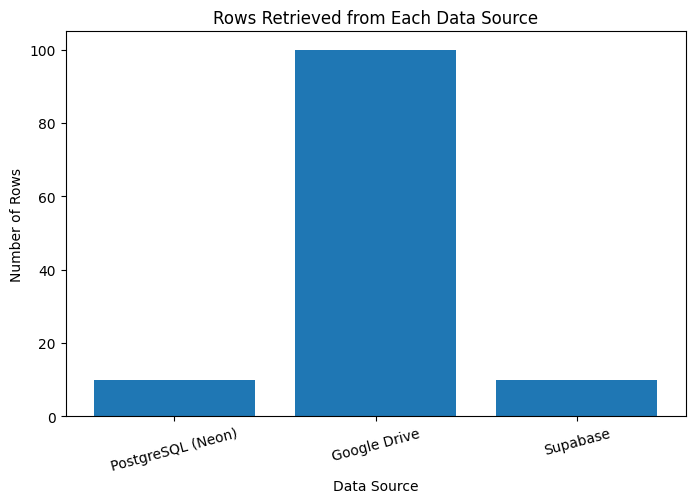

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(
    comparison_summary["Data Source"],
    comparison_summary["Rows Retrieved"]
)
plt.title("Rows Retrieved from Each Data Source")
plt.xlabel("Data Source")
plt.ylabel("Number of Rows")
plt.xticks(rotation=15)
plt.show()

In [25]:
validation_df = pd.DataFrame({
    "Data Source": ["Original", "PostgreSQL", "Google Drive", "Supabase"],
    "Rows": [
        len(ecommerce_df),
        len(postgres_df),
        len(drive_df),
        len(supabase_df)
    ],
    "Columns": [
        ecommerce_df.shape[1],
        postgres_df.shape[1],
        drive_df.shape[1],
        supabase_df.shape[1]
    ]
})

validation_df

,Data Source,Rows,Columns
0,Original,100,11
1,PostgreSQL,10,11
2,Google Drive,100,11
3,Supabase,10,11


In [28]:
import time

timings = []

# PostgreSQL
start = time.time()
pd.read_sql("SELECT * FROM ecommerce_orders LIMIT 10;", engine)
timings.append(("PostgreSQL", time.time() - start))

# Google Drive
start = time.time()
pd.read_csv(drive_csv_path)
timings.append(("Google Drive", time.time() - start))

# Supabase
start = time.time()
supabase.table("ecommerce_orders").select("*").limit(10).execute()
timings.append(("Supabase", time.time() - start))

timing_df = pd.DataFrame(timings, columns=["Source", "Time (seconds)"])
timing_df

,Source,Time (seconds)
0,PostgreSQL,7.242484
1,Google Drive,0.006327
2,Supabase,0.766269


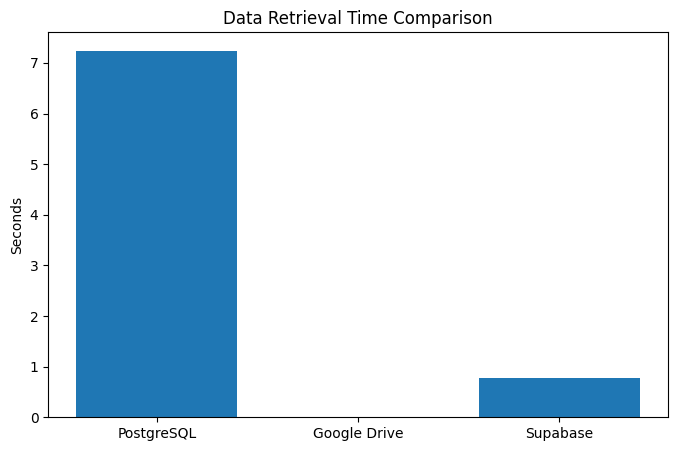

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(timing_df["Source"], timing_df["Time (seconds)"])
plt.title("Data Retrieval Time Comparison")
plt.ylabel("Seconds")
plt.show()

In [30]:
data_dictionary = pd.DataFrame({
    "Column": ecommerce_df.columns,
    "Description": [
        "Unique order identifier",
        "Customer name",
        "Product category",
        "Product name",
        "Number of items purchased",
        "Price per item",
        "Total order value",
        "Date of order",
        "Customer city",
        "Payment method",
        "Order status"
    ]
})

data_dictionary

,Column,Description
0,order_id,Unique order identifier
1,customer_name,Customer name
2,product_category,Product category
3,product_name,Product name
4,quantity,Number of items purchased
5,unit_price,Price per item
6,total_amount,Total order value
7,order_date,Date of order
8,city,Customer city
9,payment_method,Payment method


In [24]:
project_summary = {
    "Notebook": "02_data_access_postgresql_drive_supabase.ipynb",
    "Dataset": "Synthetic E-Commerce Orders",
    "Total Records": len(ecommerce_df),
    "Total Features": ecommerce_df.shape[1],
    "PostgreSQL Provider": "Neon",
    "Cloud Storage": "Google Drive",
    "Backend Service": "Supabase",
    "Libraries Used": "pandas, sqlalchemy, psycopg2, supabase",
}

pd.DataFrame(project_summary.items(), columns=["Parameter", "Value"])

,Parameter,Value
0,Notebook,02_data_access_postgresql_drive_supabase.ipynb
1,Dataset,Synthetic E-Commerce Orders
2,Total Records,100
3,Total Features,11
4,PostgreSQL Provider,Neon
5,Cloud Storage,Google Drive
6,Backend Service,Supabase
7,Libraries Used,"pandas, sqlalchemy, psycopg2, supabase"
